# 1_Core Qiskit 2.x workflow

This chapter gives a compact tour of the basic Qiskit 2.x workflow:

1. create a circuit,
2. run a primitive,
3. transpile when needed,
4. define an observable,
5. estimate a quantity of interest (*Observable*),
6. and understand how execution modes are chosen in Qiskit Runtime.


## 1-1. Overview of the Workflow

A typical Qiskit 2.x workflow is built from a few standard Qiskit objects.

- A **circuit** prepares a quantum state or computation.
- A **primitive** executes a specific task.
  - **Sampler** returns sampled measurement data.
  - **Estimator** returns expectation values of observables.
- **Transpilation** prepares a circuit for a target execution environment.
- An **observable** specifies what physical quantity we want to evaluate.
- A **mode** determines how Runtime jobs are scheduled on IBM Quantum resources.

Those are mapped to Qiskit pattern:
![qiskit_pattern.png](images/qiskit_pattern.png)

### Check the installed Qiskit version

In [ ]:
import qiskit
qiskit.__version__  # should be > 2.0

'2.3.0'


--------

## 1-2. Execution with primitives: a first `Sampler` example

We begin with the most direct replacement for “run a circuit and get outcomes”:
the **Sampler** primitive.

In the next cell, we create a **two-qubit Bell-state circuit**, measure all qubits, and send the circuit to `StatevectorSampler`.
Since this is a statevector-based local primitive, the example is easy to inspect and does not require a real backend.


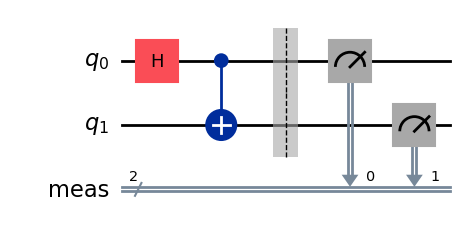

In [1]:
from qiskit.circuit import QuantumCircuit
from qiskit.primitives import StatevectorSampler
from qiskit.visualization import plot_histogram

# 1. Build a quantum circuit
qc = QuantumCircuit(2)
qc.h(0)
qc.cx(0,1)
qc.measure_all()

qc.draw("mpl")


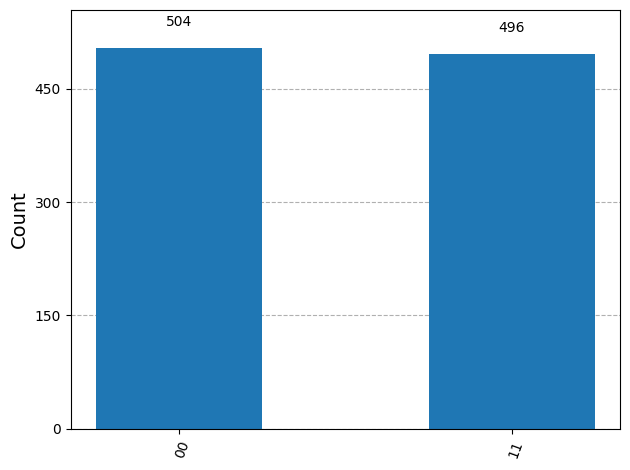

In [3]:
sampler = StatevectorSampler()
job = sampler.run([qc], shots=1000)

result = job.result()
plot_histogram(result[0].data.meas.get_counts())

This is the most basic workflow (Qiskit pattern):

1. build a circuit,
2. (skipped in the emulator example here) map the circuit to a real backend, (Transpilation)
3. run a sampler (primitive),
4. inspect the returned measurement data.

For this Bell-state circuit, the dominant outcomes should be `00` and `11`.


### Exercise 1

Modify the example so that it prepares a **3-qubit GHZ state** and run it with the sampler.

Suggested steps:

1. create a 3-qubit circuit,
2. apply `H` to qubit 0,
3. apply two `CX` gates to spread the entanglement (`cx(0, 1)` and `cx(1, 2)`).
4. measure all qubits,
5. run the circuit with `StatevectorSampler`.

Which bitstrings should dominate the result?


In [ ]:
# Your code here



Answer

```python
qc_ex = QuantumCircuit(3)
qc_ex.h(0)
qc_ex.cx(0,1)
qc_ex.cx(1,2)
qc_ex.measure_all()
qc_ex.draw("mpl")

job_ex = sampler.run([qc_ex], shots=1000)
result_ex = job_ex.result()
plot_histogram(result_ex[0].data.meas.get_counts())
```


--------

## 1-3. Hardware-aware transpilation with a preset pass manager

Qiskit circuits are usually written at an **abstract level**:
we describe what computation we want, not yet how a specific device must realize it.

Before execution on hardware, the circuit must be rewritten into a form that respects
- the backend's native gate set,
- connectivity constraints, and 
- optimization opportunities.
  
This is the role of the **transpiler**.

First, we load the target backend in the next cell.
Visit [https://quantum.cloud.ibm.com/computers](https://quantum.cloud.ibm.com/computers) for available backends.


In [ ]:
from qiskit_ibm_runtime import QiskitRuntimeService

service = QiskitRuntimeService()
# This may take a few seconds as it fetches the latest backend information.
# backend = service.least_busy(operational=True, simulator=False, min_num_qubits=4)
# Or by name:
backend = service.backend(backend_name)

qiskit_runtime_service.__init__:WARNING:2026-03-27 04:48:45,818: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (internal, premium), the available account instances are: Solutions Demo internal fleet, Educational premium fleet, Educational internal fleet, Solutions Notebooks internal fleet, Solutions Notebooks premium fleet, Solutions Demo premium fleet, Solutions Demo internal fleet, Solutions Notebooks premium fleet, Educational premium fleet, Solutions Notebooks internal fleet, Solutions Demo premium fleet, Educational internal fleet. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-03-27 04:48:45,818: Using instance: Solutions Notebooks premium fleet, plan: premium


Qiskit 2.x encourages users to start from a built-in preset workflow through
`generate_preset_pass_manager(...)`, rather than manually assembling long pass pipelines for common use cases.
In the next cell, we show a basic transpilation.

Circuit before transpilation:
Depth =  3


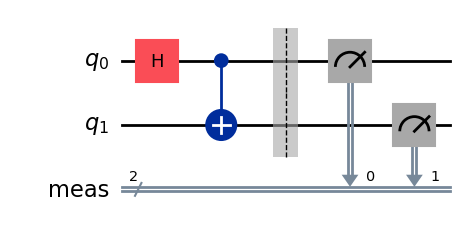

In [66]:
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

pm = generate_preset_pass_manager(backend=backend, optimization_level=3)
transpiled_circuit = pm.run(qc)

print("Circuit before transpilation:")
print("Depth = ", qc.depth())
qc.draw("mpl")

Circuit after transpilation:
Depth =  7


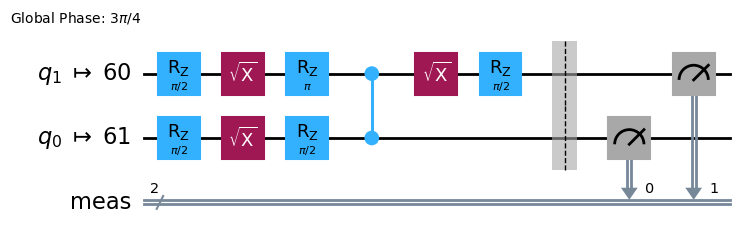

In [67]:
print("Circuit after transpilation:")
print("Depth = ", transpiled_circuit.depth())
transpiled_circuit.draw("mpl")

The circuit you write (`qc`) is not necessarily the circuit that will be executed.

A preset pass manager convert the circuit so that matches to the backend.
The passes include:
- layout selection,
- routing on limited connectivity,
- basis-gate translation,
- and circuit optimization.


### Exercise 2

For a given deep random circuit, try several optimization levels and compare the transpiled circuits.

Suggested steps:

1. generate pass managers with optimization levels `0`, `1`, `2`, and `3`,
2. run each pass manager on the same circuit,
3. compare the resulting circuit depths.

Which optimization level gives the shallowest circuit for this example?
Does the answer always have to be the same for every circuit?


Depth of the original circuit: 101


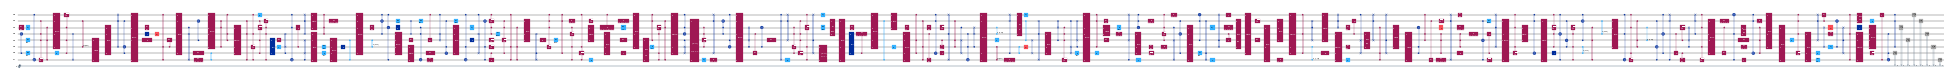

In [68]:
from qiskit.circuit.random import random_circuit

qc_ex2 = random_circuit(num_qubits=8, depth=100, measure=True, seed=1234)
print("Depth of the original circuit:", qc_ex2.depth())    
qc_ex2.draw("mpl", scale=0.1, fold=-1)


In [69]:
# Write your code here

Answer:

```python
for opt_level in range(4):
    pm_ex2 = generate_preset_pass_manager(backend=backend, optimization_level=opt_level)
    qc_ex2_opt = pm_ex2.run(qc_ex2)
    print(qc_ex2_opt.depth())
```


--------

## 1-4. Observables and expectation values

The second major primitive after `Sampler` is the **`Estimator`**.
Whereas the sampler returns measurement information, the estimator is used when we want the expectation value of an observable.

In Qiskit 2.x, observables are represented explicitly using operator classes such as `SparsePauliOp`.
This is a particularly important pattern for quantum chemistry and variational algorithms, where Hamiltonians are naturally written as sums of Pauli strings,
$$
H = \sum_i c_i P_i.
$$


In [70]:
from qiskit.quantum_info import SparsePauliOp

observable = SparsePauliOp.from_list([("ZZ",1)])

observable

SparsePauliOp(['ZZ'],
              coeffs=[1.+0.j])

`SparsePauliOp` is the standard way to write observables built from Pauli strings.

Once the observable is defined, we can pair it with a circuit and evaluate its expectation value.


In [71]:
from qiskit.primitives import StatevectorEstimator

estimator = StatevectorEstimator()

qc = QuantumCircuit(2)
qc.h(0)
qc.cx(0,1)

# Unlike the sampler, the estimator should not include measurements.
job = estimator.run([(qc, observable)])
print("Expectation value:", job.result()[0].data.evs)

Expectation value: 0.9999999999999998


In the code above, we calculated:
$$
\begin{aligned}
&\left[\frac{1}{\sqrt{2}}\left(\langle 00| + \langle 11| \right)\right] (ZZ) \left[\frac{1}{\sqrt{2}}\left(| 00\rangle + | 11\rangle \right)\right] \\ =&\frac{1}{2}\left(\langle 00| ZZ | 00 \rangle + \langle 11| ZZ | 11 \rangle + \langle 00| ZZ |11\rangle + \langle 11| ZZ | 00 \rangle \right)\\
=&\frac{1}{2}(1+1+0+0)=1.
\end{aligned}
$$

In the estimator call, the relevant conceptual unit is the pair

- **circuit**: prepares the quantum state,
- **observable**: defines what quantity is being measured on that state.

### Exercise 3

Consider the three-qubit GHZ state
$$
|\psi\rangle = \frac{1}{\sqrt{2}}\left(|000\rangle + |111\rangle\right).
$$

Prepare this state with a Hadamard gate on qubit 0, followed by CNOT gates from qubit 0 to qubits 1 and 2.

Define the observable
$$
H = Z \otimes Z \otimes I + I \otimes Z \otimes Z + X \otimes X \otimes X
$$
with `SparsePauliOp`, and evaluate
$$
\langle \psi | H | \psi \rangle
$$
using `StatevectorEstimator`.

Suggested steps:

1. construct the observable from Pauli strings,
2. build a circuit that prepares the GHZ state,
3. run the estimator,
4. compare the numerical result with the expected value from the state structure.

In [72]:
# Your code here

Answer

```python
# 3-qubit GHZ state circuit
qc_ghz = QuantumCircuit(3)
qc_ghz.h(0)
qc_ghz.cx(0, 1)
qc_ghz.cx(0, 2)

# Observable H = ZZI + IZZ + XXX
observable_ghz = SparsePauliOp.from_list(
    [("ZZI", 1), ("IZZ", 1), ("XXX", 1)]
)

# Evaluate expectation with StatevectorEstimator
estimator = StatevectorEstimator()
job_ghz = estimator.run([(qc_ghz, observable_ghz)])
result_ghz = job_ghz.result()

print("Expectation value:", result_ghz[0].data.evs)
# Expected value for GHZ is 3
```

### Observable mapping to the backend

When we define an observable such as a `SparsePauliOp`, it is usually written in terms of the qubits in the algorithm-level circuit.  
However, after transpilation, the circuit may be rewritten onto physical qubits of the target backend, with the different final qubit layout.

Because of this, the observable should be mapped to the transpiled circuit layout before execution.  
In Qiskit, this is done with:

$$
\texttt{obs\_isa = obs.apply\_layout(qc\_isa.layout)}
$$

So the simple workflow is:

1. define the circuit and observable in the abstract problem,
2. transpile the circuit for the backend,
3. apply the transpiled layout to the observable,
4. run the mapped circuit-observable pair with the Estimator.

This keeps the observable consistent with the qubit assignment actually used by the backend.

In [ ]:
obs_isa = observable.apply_layout(transpiled_circuit.layout)
print("Original observable:", observable)
print("Observable after applying layout:", obs_isa)
print("Circuit Layout:", '\n'.join(transpiled_circuit.layout.initial_layout.__repr__().split('\n')[:5]), "\n...")

Observable after applying layout: SparsePauliOp(['IIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIZZIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIII'],
              coeffs=[1.+0.j])



--------

## 1-5. Runtime execution modes

When we use **Qiskit Runtime** on IBM Quantum resources, we choose an execution mode when we create the primitive.

The three main modes are:

- **Job mode**: submit one primitive request directly to a backend.
- **Session mode**: keep an interactive workload grouped together, which is useful when later jobs depend on earlier results.
- **Batch mode**: submit a collection of independent jobs together.

![batch_session.png](images/batch_session.png)

The important point is that the primitive interface stays almost the same.  
What changes is the `mode=...` object passed to `Sampler` or `Estimator`.


In [ ]:
from qiskit_ibm_runtime import (
    SamplerV2 as Sampler,
    EstimatorV2 as Estimator,
    Session,
    Batch,
)

# Job mode: one primitive request directly on a backend
sampler_job = Sampler(mode=backend)

# Session mode: useful for iterative workloads, open-access users cannot use this mode.
'''
with Session(backend=backend, max_time="2m") as session:
    sampler_session = Sampler(mode=session)
    result_sampler_session = sampler_session.run([transpiled_circuit]).result()
    estimator_session = Estimator(mode=session)
    result_estimator_session = estimator_session.run([(transpiled_circuit, obs_isa)]).result()
'''

# Batch mode: useful for a collection of independent jobs
with Batch(backend=backend, max_time="2m") as batch:
    sampler_batch = Sampler(mode=batch)
    result_sampler_batch = sampler_batch.run([transpiled_circuit]).result()
    estimator_batch = Estimator(mode=batch)
    result_estimator_batch = estimator_batch.run([(transpiled_circuit, obs_isa)]).result()


### Exercise 4

Suppose you want to evaluate one fixed circuit-observable pair only once.  
Which execution mode is the most natural?

Now suppose you are repeatedly updating parameters based on previous results.  
Which mode would better match that workflow, and why?


------

## Conclusion

This chapter introduced the basic Qiskit 2.x workflow through a sequence of small examples.

We created circuits, sampled measurement results, transpiled circuits, worked with parameters, defined observables, estimated expectation values, and then connected those ideas to the three main Runtime execution modes.
